In [105]:
import sqlite3
import pandas as pd
import numpy as np

DB_PATH = "/Users/darraghdonnelly/dev/Database/recovered.db"
TEST_SIZE = 0.20

# connect to db
with sqlite3.connect(DB_PATH) as conn:
    df = pd.read_sql_query(
        f"SELECT src, sex, age, distance_m, time_s FROM concat_results",
        conn,
    )

print(f"rows: {len(df)}")
df.head()

rows: 143442


,src,sex,age,distance_m,time_s
0,CherryBlossom2017,1,21,16093,3217.0
1,CherryBlossom2017,1,22,16093,3232.0
2,CherryBlossom2017,1,31,16093,3276.0
3,CherryBlossom2017,1,33,16093,3285.0
4,CherryBlossom2017,1,35,16093,3288.0


In [106]:
df["distance_bucket"] = (
    df["distance_m"].round().astype(int)
    .map({42195: "42k", 16093: "16k", 5000: "5k"})
)

df["distance_bucket"].head

<bound method NDFrame.head of 0         16k
1         16k
2         16k
3         16k
4         16k
         ... 
143437    16k
143438    16k
143439    16k
143440    16k
143441    16k
Name: distance_bucket, Length: 143442, dtype: str>

In [107]:
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score

# split dataset into train and test - stratified by distance
train_df, test_df = train_test_split(df, test_size=TEST_SIZE, random_state=42, stratify=df["distance_bucket"])

# store features in list
features = ["distance_m", "age", "sex"]

X_train = train_df[features]

# set target to time
y_train = train_df["time_s"]

# convert distances to labeled buckets (5k, 16k, 42k) so stratified k folding can be done
train_buckets = train_df["distance_bucket"]

X_test = test_df[features]
y_test = test_df["time_s"]

rf = RandomForestRegressor(n_estimators=200, max_depth=3, min_samples_leaf=2)

skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

# get mean abs error
cv_mae = -cross_val_score(
    rf,
    X_train,
    y_train,
    cv = skf.split(X_train, train_buckets),     # carry out strat kfold on training data for the 3 distances
    scoring="neg_mean_absolute_error"
)

# get r sqrd value
cv_r2 = cross_val_score(
    rf,
    X_train,
    y_train,
    cv=skf.split(X_train, train_buckets),
    scoring="r2"
)

print("CV MAE:", cv_mae.mean(), "with standard deviation of ±", cv_mae.std())
print("CV R2:", cv_r2.mean(), "with standard deviation of ±", cv_r2.std())


rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)

print("Test R2:", r2_score(y_test, y_pred))

CV MAE: 2220.9127696822093 with standard deviation of ± 6.355905192715515
CV R2: 0.7228272670523473 with standard deviation of ± 0.001404121412127468
Test R2: 0.7205892020548499


In [108]:
from sklearn.metrics import mean_absolute_error

# print out the mae mins for each bucket in test
test_eval = test_df.copy()
test_eval["pred_time_s"] = y_pred
test_eval["actual_time_s"] = y_test.values

for bucket in ["5k", "16k", "42k"]:
    bucket_rows = test_eval[test_eval["distance_bucket"] == bucket]
    mae_seconds = mean_absolute_error(bucket_rows["actual_time_s"], bucket_rows["pred_time_s"])
    mae_minutes = mae_seconds / 60

    print(bucket)
    print("MAE minutes:", mae_minutes)
    print()

5k
MAE minutes: 7.657475853786289

16k
MAE minutes: 12.516322416402675

42k
MAE minutes: 45.83599842946573



In [109]:
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold

param_grid = {
    "n_estimators": [100, 200, 300, 500],
    "max_depth": [5, 10, 15, 20, None],
    "min_samples_leaf": [1, 2, 4]
}

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

# randomised search used instead of gridsearch due to the large hp space
search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_grid,
    n_iter=10,
    scoring="neg_mean_absolute_error",
    cv=cv.split(X_train, train_buckets),
    random_state=42,
    n_jobs=-1,
)

search.fit(X_train, y_train)

print(search.best_params_)
print(-search.best_score_)


{'n_estimators': 200, 'min_samples_leaf': 2, 'max_depth': 5}
2190.9948757096167


In [110]:
import numpy as np
from sklearn.metrics import mean_absolute_error
from sklearn.model_selection import train_test_split

# convert distance and time (target) to log scale for Reigel model, store in dataframes
df["log_distance"] = np.log(df["distance_m"].astype(float))
y_log = np.log(df["time_s"].astype(float))

# get aged squared so nonliner relationship can be represented
df["ageSqrd"] = df["age"] ** 2

# set features and targets for log model
X = df[["log_distance", "age", "ageSqrd", "sex"]]

# split data into train test
X_train, X_test, y_train, y_test = train_test_split(
    X, y_log, test_size=TEST_SIZE, random_state=42
)

model = RandomForestRegressor(n_estimators=200, max_depth=3, min_samples_leaf=2)
model.fit(X_train, y_train)

log_pred = model.predict(X_test)

# predict time in secs 
pred_log = model.predict(X_test)

# convert log predictions to seconds by getting the exponential
mae_s = round(mean_absolute_error(np.exp(y_test), np.exp(pred_log)), 2)

print("MAE seconds:", mae_s, "->", round(mae_s/60, 2), "min")

MAE seconds: 2213.77 -> 36.9 min


In [115]:
# prediction function that reads distance, age and sex - returns time in secs
def predict_time_seconds(distance_m: float, age: float, sex: int) -> float:
    x = pd.DataFrame([{
        "log_distance": np.log(float(distance_m)),
        "age": float(age),
        "ageSqrd": float(age ** 2),
        "sex": float(sex)
    }])
    return float(np.exp(model.predict(x)[0]))

# func to format time into hh:mm:ss
def format_time(seconds: float) -> str:
    s = int(round(seconds))
    h = s // 3600
    m = (s % 3600) // 60
    sec = s % 60
    return f"{h}:{m:02d}:{sec:02d}"

ages = [10, 20, 30, 40, 50, 60]
distances = {
    "5k": 5000,
    "10 mile": 16093,
    "marathon": 42195,
}


for distance_name, distance_m in distances.items():
    print(distance_name)

    for age in ages:
        male_pred = format_time(predict_time_seconds(distance_m, age, 0))
        female_pred = format_time(predict_time_seconds(distance_m, age, 1))

        print(f"Age {age}: male {male_pred} vs female {female_pred}")

    print()


5k
Age 10: male 0:36:13 vs female 0:36:17
Age 20: male 0:36:13 vs female 0:36:17
Age 30: male 0:36:13 vs female 0:36:17
Age 40: male 0:40:22 vs female 0:40:27
Age 50: male 0:40:54 vs female 0:40:59
Age 60: male 0:41:07 vs female 0:41:12

10 mile
Age 10: male 1:28:31 vs female 1:39:23
Age 20: male 1:28:31 vs female 1:39:23
Age 30: male 1:28:31 vs female 1:39:23
Age 40: male 1:28:31 vs female 1:39:23
Age 50: male 1:28:31 vs female 1:39:23
Age 60: male 1:28:31 vs female 1:39:23

marathon
Age 10: male 4:10:38 vs female 4:40:24
Age 20: male 4:10:38 vs female 4:40:24
Age 30: male 4:10:38 vs female 4:40:24
Age 40: male 4:10:38 vs female 4:40:24
Age 50: male 4:10:38 vs female 5:05:55
Age 60: male 4:52:07 vs female 5:06:14



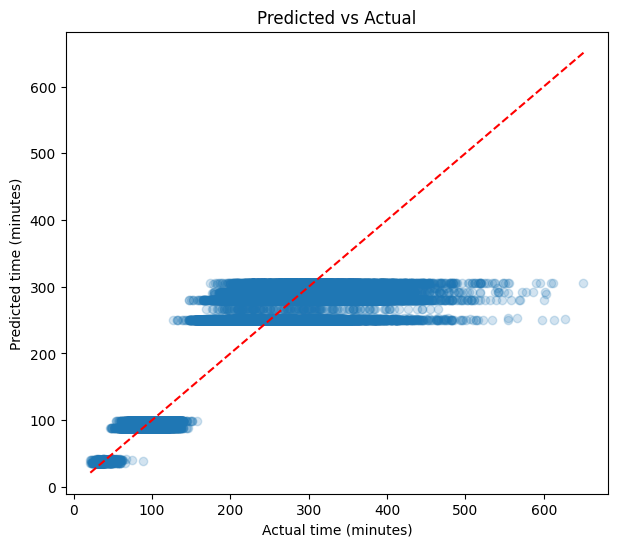

In [127]:
import numpy as np
import matplotlib.pyplot as plt

actual_minutes = np.exp(y_test) / 60
pred_minutes = np.exp(y_pred) / 60

plt.figure(figsize=(7, 6))
plt.scatter(actual_minutes, pred_minutes, alpha=0.2)
plt.plot(
    [actual_minutes.min(), actual_minutes.max()],
    [actual_minutes.min(), actual_minutes.max()],
    "r--"
)
plt.xlabel("Actual time (minutes)")
plt.ylabel("Predicted time (minutes)")
plt.title("Predicted vs Actual")
plt.show()